In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from torch.utils.data.dataset import Dataset
from torchvision import transforms

In [2]:
df = pd.read_csv(r'C:\Users\iqvbr\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_metadata.csv')

In [3]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [4]:
df['image_id'][0]

'ISIC_0027419'

In [5]:
placeholder = dict(df['dx'].value_counts())

<BarContainer object of 7 artists>

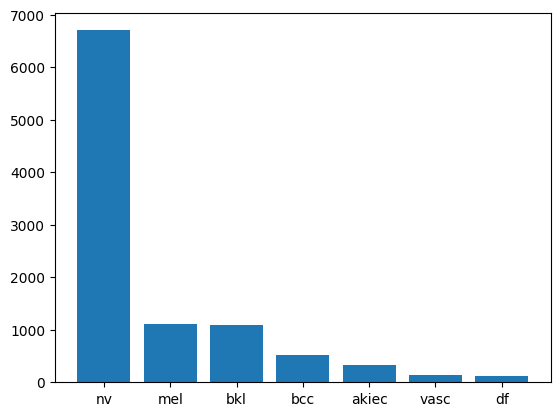

In [6]:
plt.bar(list(placeholder.keys()),list(placeholder.values()))

In [7]:
path = Path(r'C:\Users\iqvbr\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\all_images')

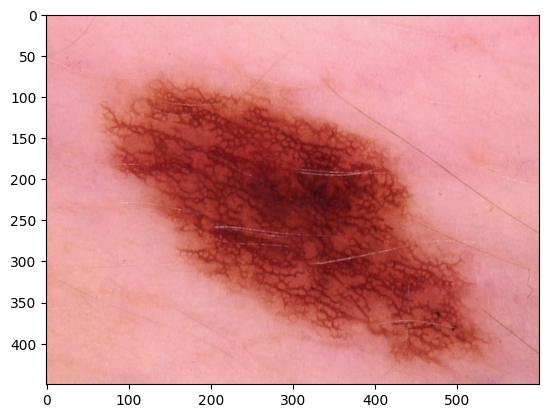

In [8]:
i=0
for img in path.iterdir():
    i+=1
    if i<=3:
        plt.imshow(Image.open(img))
    else:
        break

In [9]:
counter = {}
for img in path.iterdir():
    image = Image.open(img)
    size = image.size
    if size in counter:
        counter[size]+=1
    else:
        counter[size]=1

In [10]:
print(counter)
#all images have size (600,450)

{(600, 450): 10015}


In [11]:
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [12]:
df.iloc[1,1]

'ISIC_0025030'

In [13]:
transform = transforms.Compose([transforms.Resize((600,450)),transforms.ToTensor()])

In [30]:
class HAMFolder(Dataset):
    def __init__(self, df, dir, transform):
        self.df = df
        self.dir = dir
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        img_path = Path(self.dir, self.df.iloc[idx,1]+'.jpg') 
        img = Image.open(img_path)
        label=self.df.iloc[idx,2]
        img = self.transform(img)
        return img,label
folder = HAMFolder(df=df,dir=path,transform=transform)

In [31]:
for thing in folder:
    print(thing)
    break

(tensor([[[0.7333, 0.7333, 0.7373,  ..., 0.7608, 0.7725, 0.7725],
         [0.7294, 0.7373, 0.7412,  ..., 0.7647, 0.7686, 0.7647],
         [0.7294, 0.7412, 0.7451,  ..., 0.7686, 0.7686, 0.7608],
         ...,
         [0.6118, 0.6157, 0.6157,  ..., 0.7059, 0.6941, 0.6863],
         [0.6078, 0.6078, 0.6157,  ..., 0.7059, 0.6941, 0.6863],
         [0.6039, 0.6039, 0.6118,  ..., 0.7020, 0.6902, 0.6824]],

        [[0.5765, 0.5843, 0.5882,  ..., 0.6078, 0.6118, 0.6157],
         [0.5843, 0.5961, 0.6000,  ..., 0.6078, 0.6157, 0.6196],
         [0.5882, 0.6000, 0.6039,  ..., 0.6078, 0.6157, 0.6196],
         ...,
         [0.4784, 0.4824, 0.4784,  ..., 0.5843, 0.5725, 0.5608],
         [0.4745, 0.4784, 0.4745,  ..., 0.5843, 0.5725, 0.5608],
         [0.4667, 0.4745, 0.4706,  ..., 0.5804, 0.5765, 0.5647]],

        [[0.7451, 0.7451, 0.7569,  ..., 0.6627, 0.6706, 0.6627],
         [0.7529, 0.7529, 0.7569,  ..., 0.6627, 0.6667, 0.6588],
         [0.7569, 0.7608, 0.7608,  ..., 0.6588, 0.6627, 0